# Разведочный анализ данных. Исследование и визуализация данных.


В качестве набора данных мы будем использовать набор данных Breast Cancer из библиотеки scikit-learn.

Этот датасет является классическим примером для задач бинарной классификации. Он содержит результаты анализа изображений клеток рака молочной железы, полученные в результате тонкоигольной аспирации. Задача состоит в том, чтобы на основе характеристик ядер клеток определить, является ли опухоль злокачественной (malignant) или доброкачественной (benign).

Датасет представляет собой готовый к использованию массив данных, не содержащий пропусков, что делает его идеальным для первичного знакомства с анализом данных.

Данные включают 30 признаков, описывающих различные характеристики ядер клеток, и целевую переменную — диагноз (злокачественная или доброкачественная). Для упрощения визуализации мы сосредоточимся на нескольких ключевых признаках.

**Описание признаков:**

- **target**: Диагноз (0 = злокачественная (malignant), 1 = доброкачественная (benign)). В исходном датасете это значения 'malignant' и 'benign'.

- **mean radius**: Среднее значение расстояния от центра до точек по периметру.

- **mean texture**: Среднее значение стандартного отклонения значений оттенков серого.

- **mean perimeter**: Средняя длина периметра.

- **mean area**: Средняя площадь.

- **mean smoothness**: Среднее значение локального сглаживания (изменение радиуса).

Для каждого изображения вычислялись три значения (среднее, стандартная ошибка и "худшее" значение) по 10 различным характеристикам, что в сумме дает 30 признаков.


In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from IPython.display import display

# Настройка стиля для графиков
%matplotlib inline
sns.set(style="ticks")

# Загрузим датасет Breast Cancer
cancer_data = load_breast_cancer()

# Создание DataFrame с признаками
df = pd.DataFrame(data=cancer_data.data, columns=cancer_data.feature_names)

# Добавление целевой переменной 'target'
df['target'] = cancer_data.target

# СОЗДАЁМ КОЛОНКУ С НАЗВАНИЯМИ КЛАССОВ
df['class_name'] = df['target'].map({i: name for i, name in enumerate(cancer_data.target_names)})

# Основные характеристики датасета

In [14]:
# 1. Размер датасета
print('Размер DataFrame:', df.shape)

# 2. Первые 5 записей
print('\nПервые 5 записей:')
display(df.head())

# 3. Информация о данных и пропусках
print('\nИнформация о данных:')
df.info()

print('\nКоличество пропусков по столбцам:')
print(df.isnull().sum())

# 4. Описательная статистика
print('\nОписательная статистика:')
display(df.describe())

# 5. Распределение целевой переменной
print('\nРаспределение классов:')
print(df['class_name'].value_counts())

Размер DataFrame: (569, 32)

Первые 5 записей:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,class_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoo

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000



Распределение классов:
class_name
benign       357
malignant    212
Name: count, dtype: int64


**Выводы по разделу**:

- Датасет содержит **569** образцов клеток.

- Каждый образец описан **30** числовыми признаками.

- Целевая переменная **target** имеет 2 уникальных значения (классы: 0 - malignant, 1 - benign).

- В данных **нет пропусков**, все признаки представлены вещественными числами (float64), а целевая переменная — целым числом (int64).

- Статистики describe() показывают, что признаки имеют очень разные масштабы. Например, mean radius варьируется от ~6 до ~28, а mean area — от ~143 до ~2500. Это важное наблюдение для дальнейшей подготовки данных.

- Классы сбалансированы достаточно хорошо: **212** злокачественных и **357** доброкачественных образцов.

# Визуальное исследование датасета


Для визуального исследования могут быть использованы различные виды диаграмм, мы построим только некоторые варианты диаграмм, которые используются достаточно часто.

1. Диаграмма рассеяния (Scatter Plot)

Позволяет построить распределение двух колонок данных и визуально обнаружить наличие зависимости.

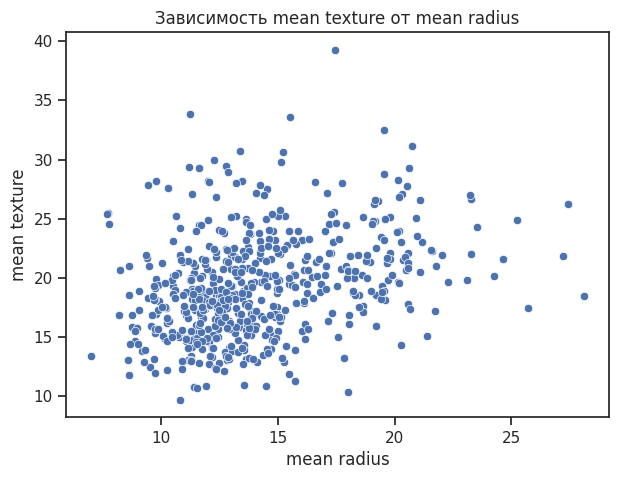

На графике видно, что точки образуют несколько кластеров, но общая зависимость прослеживается не очень четко.


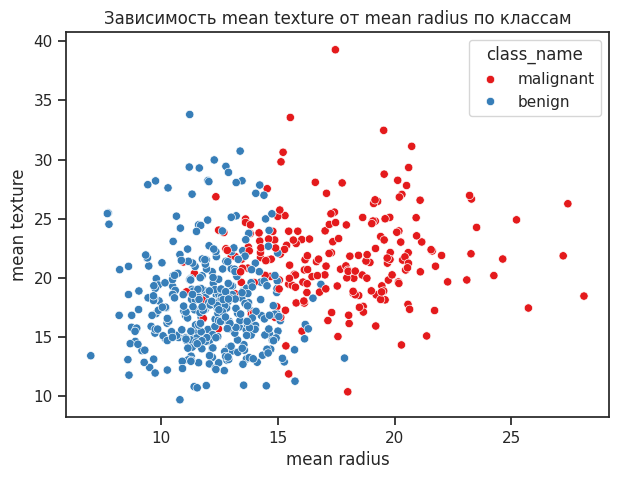

Наблюдение: точки разных классов образуют относительно обособленные кластеры. Это говорит о том, что комбинация этих двух признаков уже неплохо разделяет опухоли на доброкачественные и злокачественные.


In [15]:
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(ax=ax, x='mean radius', y='mean texture', data=df)
ax.set_title('Зависимость mean texture от mean radius')
plt.show()
print("На графике видно, что точки образуют несколько кластеров, но общая зависимость прослеживается не очень четко.")

# Посмотрим, как на эту зависимость влияет целевой признак (диагноз)
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(ax=ax, x='mean radius', y='mean texture', data=df, hue='class_name', palette='Set1')
ax.set_title('Зависимость mean texture от mean radius по классам')
plt.show()
print("Наблюдение: точки разных классов образуют относительно обособленные кластеры. Это говорит о том, что комбинация этих двух признаков уже неплохо разделяет опухоли на доброкачественные и злокачественные.")

2. Гистограмма (Histogram)

Позволяет оценить плотность вероятности распределения данных.

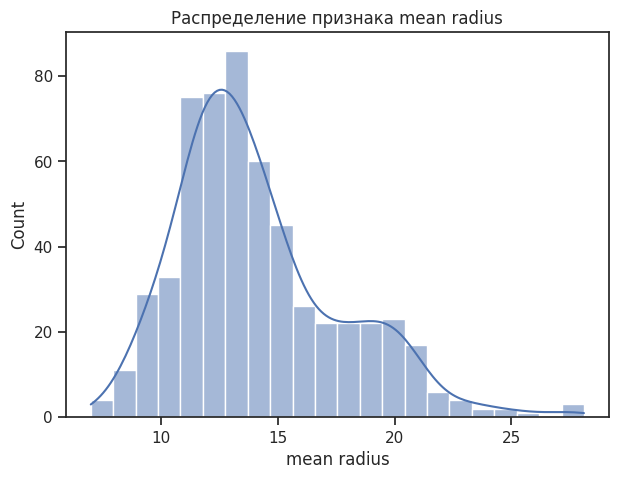

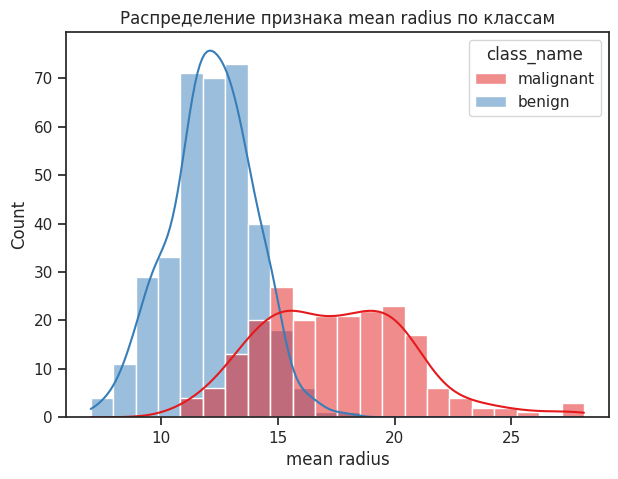

Гистограмма наглядно демонстрирует, что распределение среднего радиуса ядра клетки различается для разных диагнозов. Злокачественные опухоли (malignant) в среднем имеют больший радиус.


In [16]:
fig, ax = plt.subplots(figsize=(7,5))
sns.histplot(data=df, x='mean radius', kde=True, ax=ax)
ax.set_title('Распределение признака mean radius')
plt.show()

# Распределение mean radius по классам
fig, ax = plt.subplots(figsize=(7,5))
sns.histplot(data=df, x='mean radius', hue='class_name', kde=True, palette='Set1', ax=ax)
ax.set_title('Распределение признака mean radius по классам')
plt.show()
print("Гистограмма наглядно демонстрирует, что распределение среднего радиуса ядра клетки различается для разных диагнозов. Злокачественные опухоли (malignant) в среднем имеют больший радиус.")


3. Комбинация гистограмм и диаграмм рассеивания.

Jointplot

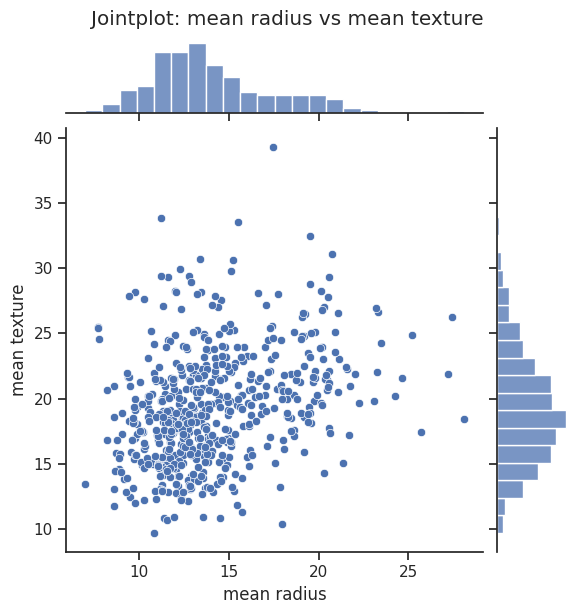

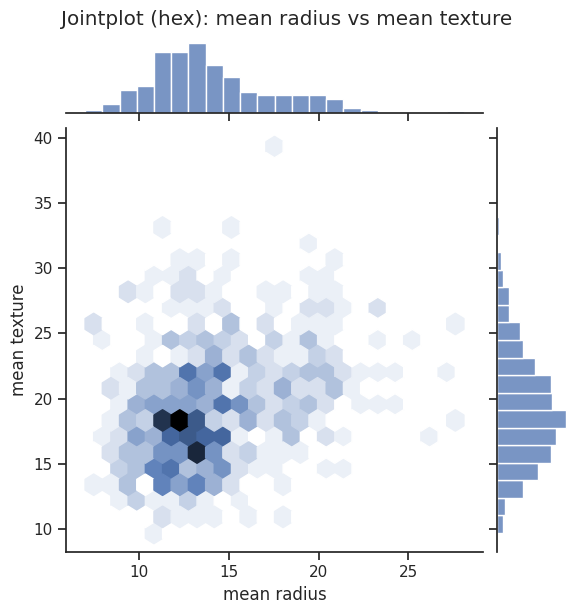

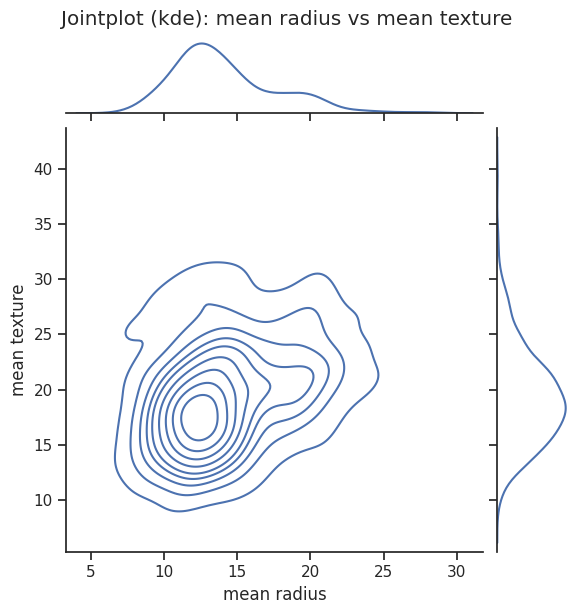

In [17]:
sns.jointplot(x='mean radius', y='mean texture', data=df)
plt.suptitle('Jointplot: mean radius vs mean texture', y=1.02)
plt.show()

sns.jointplot(x='mean radius', y='mean texture', data=df, kind="hex")
plt.suptitle('Jointplot (hex): mean radius vs mean texture', y=1.02)
plt.show()

sns.jointplot(x='mean radius', y='mean texture', data=df, kind="kde")
plt.suptitle('Jointplot (kde): mean radius vs mean texture', y=1.02)
plt.show()

4. "Парные диаграммы" (Pairplot)

Комбинация гистограмм и диаграмм рассеивания для всего набора данных.

Выводится матрица графиков. На пересечении строки и столбца, которые соответствуют двум показателям, строится диаграмма рассеивания. В главной диагонали матрицы строятся гистограммы распределения соответствующих показателей.

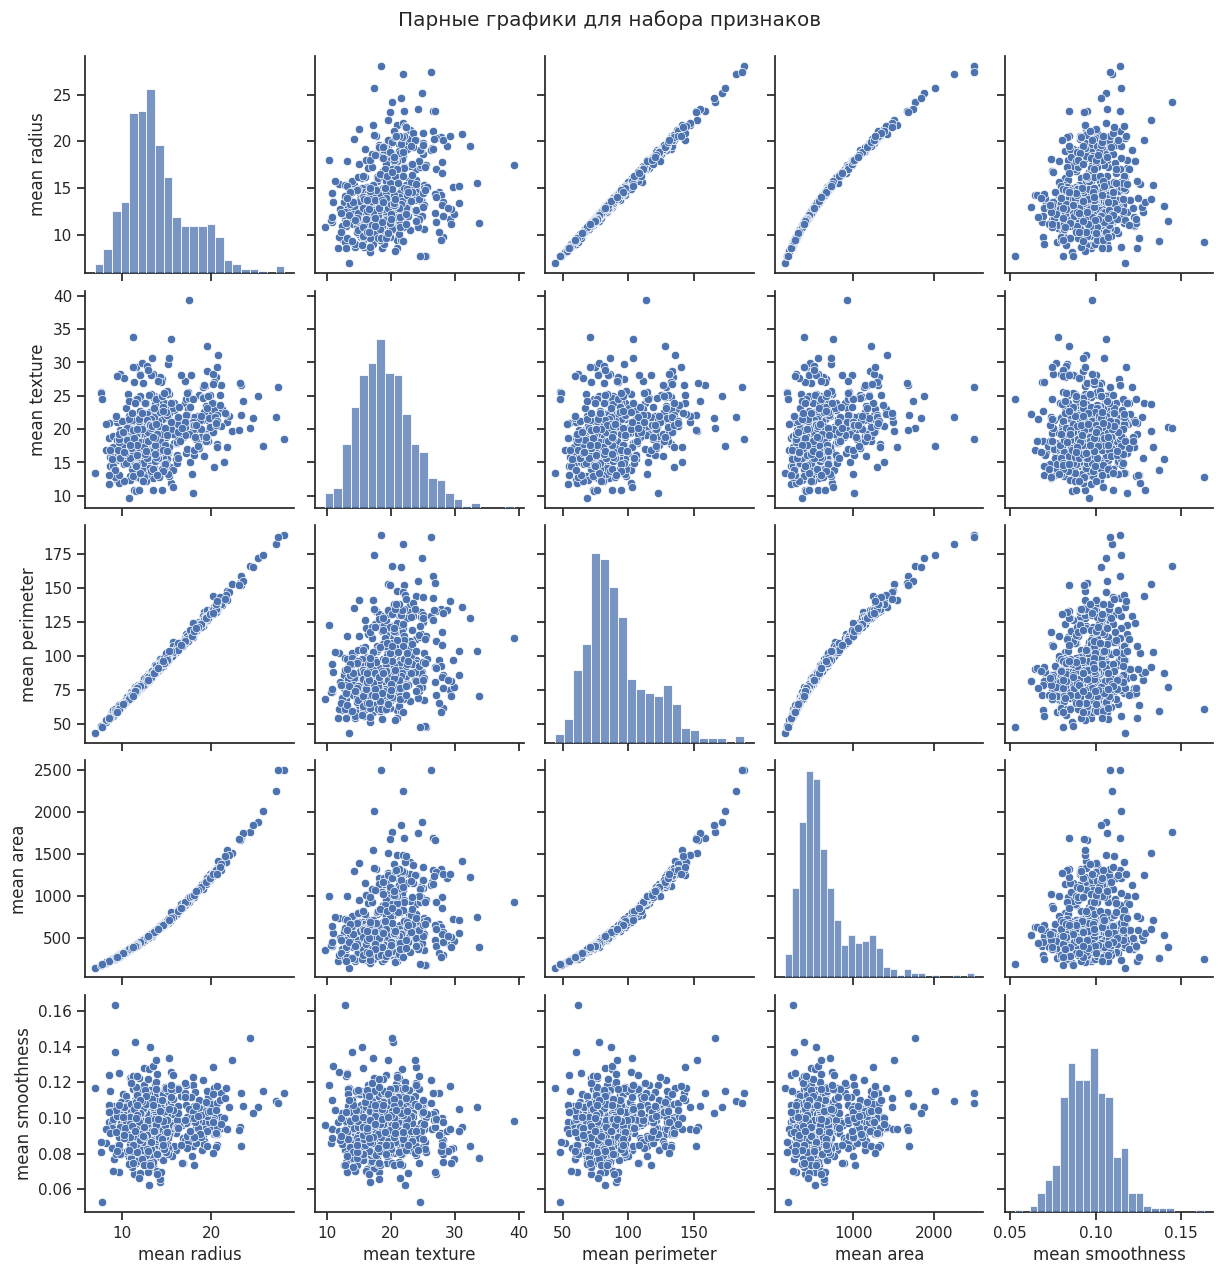

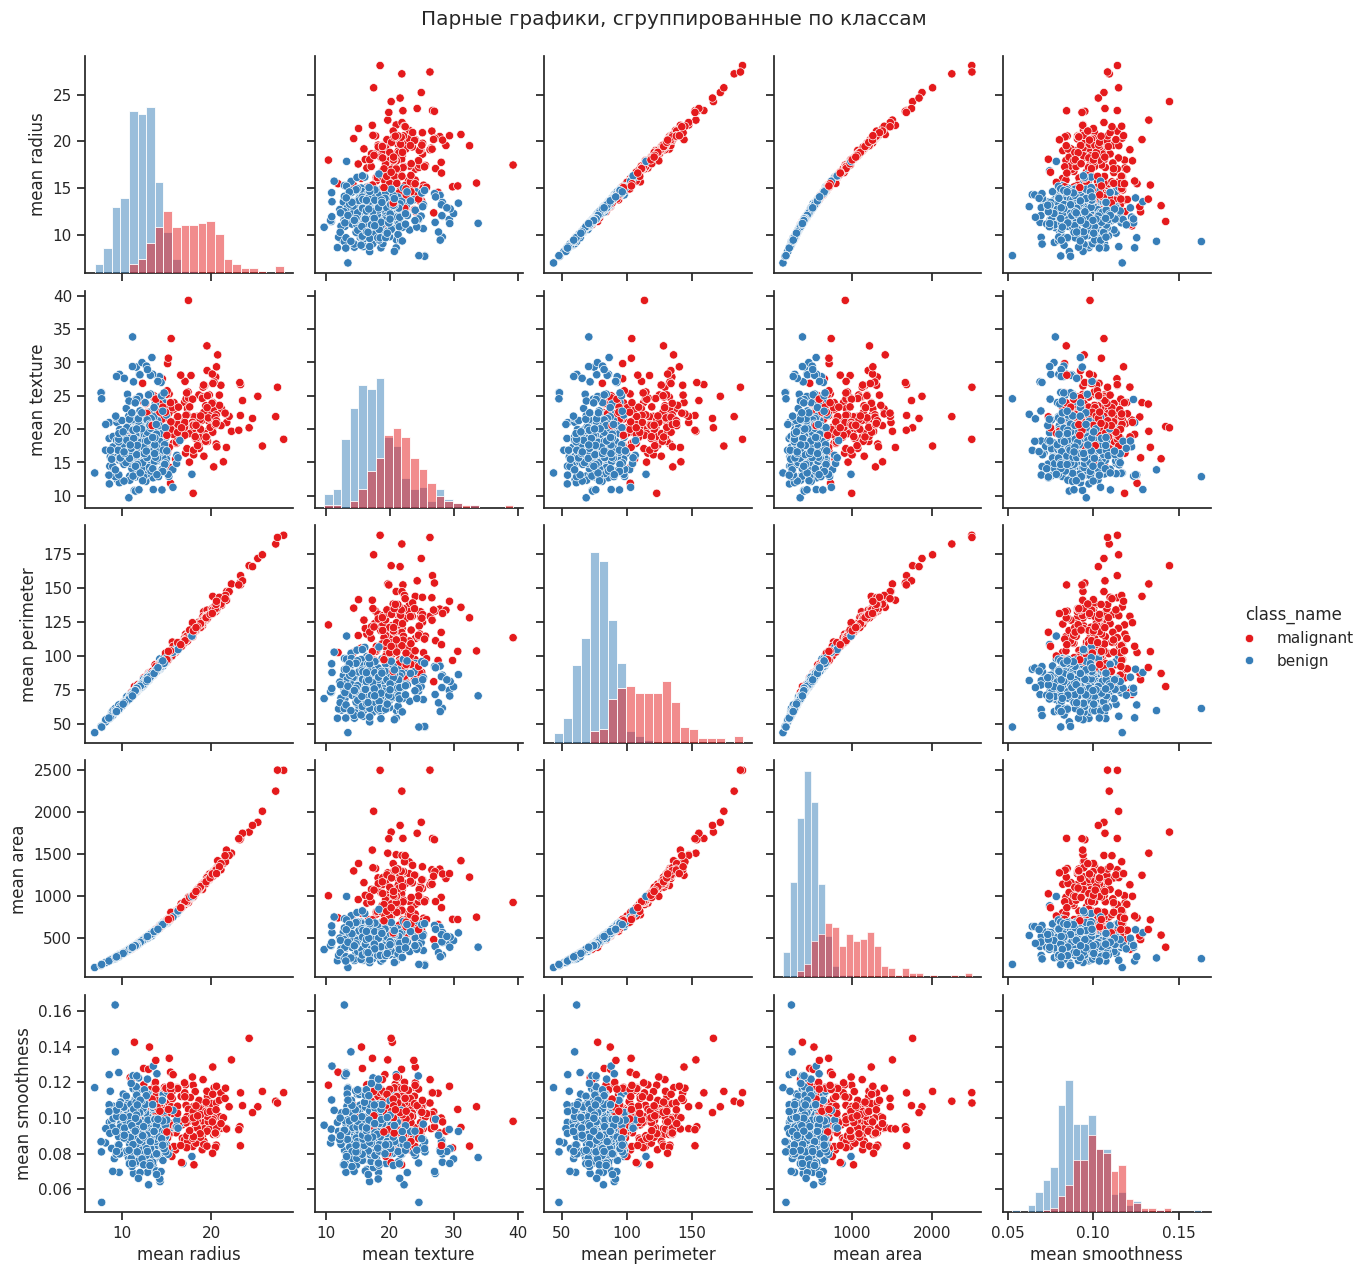

Pairplot — очень мощный инструмент. На нем хорошо видно, какие пары признаков лучше всего разделяют классы. Например, 'mean radius' и 'mean perimeter' выглядят очень информативными.


In [18]:
# Выберем несколько ключевых признаков для визуализации, чтобы график не был перегружен
selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
sns.pairplot(df[selected_features])
plt.suptitle('Парные графики для набора признаков', y=1.02)
plt.show()

# Сгруппированные по целевому признаку
selected_features_for_hue = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'class_name']
sns.pairplot(df[selected_features_for_hue], hue='class_name', palette='Set1', diag_kind='hist')
plt.suptitle('Парные графики, сгруппированные по классам', y=1.02)
plt.show()
print("Pairplot — очень мощный инструмент. На нем хорошо видно, какие пары признаков лучше всего разделяют классы. Например, 'mean radius' и 'mean perimeter' выглядят очень информативными.")

5. Ящик с усами (Box Plot)

Позволяет визуализировать медиану, квартили и выбросы в данных. Очень полезен для сравнения распределений между разными категориями.

/tmp/ipykernel_732/362238760.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], x='class_name', y='mean area', data=df, palette='Set1')


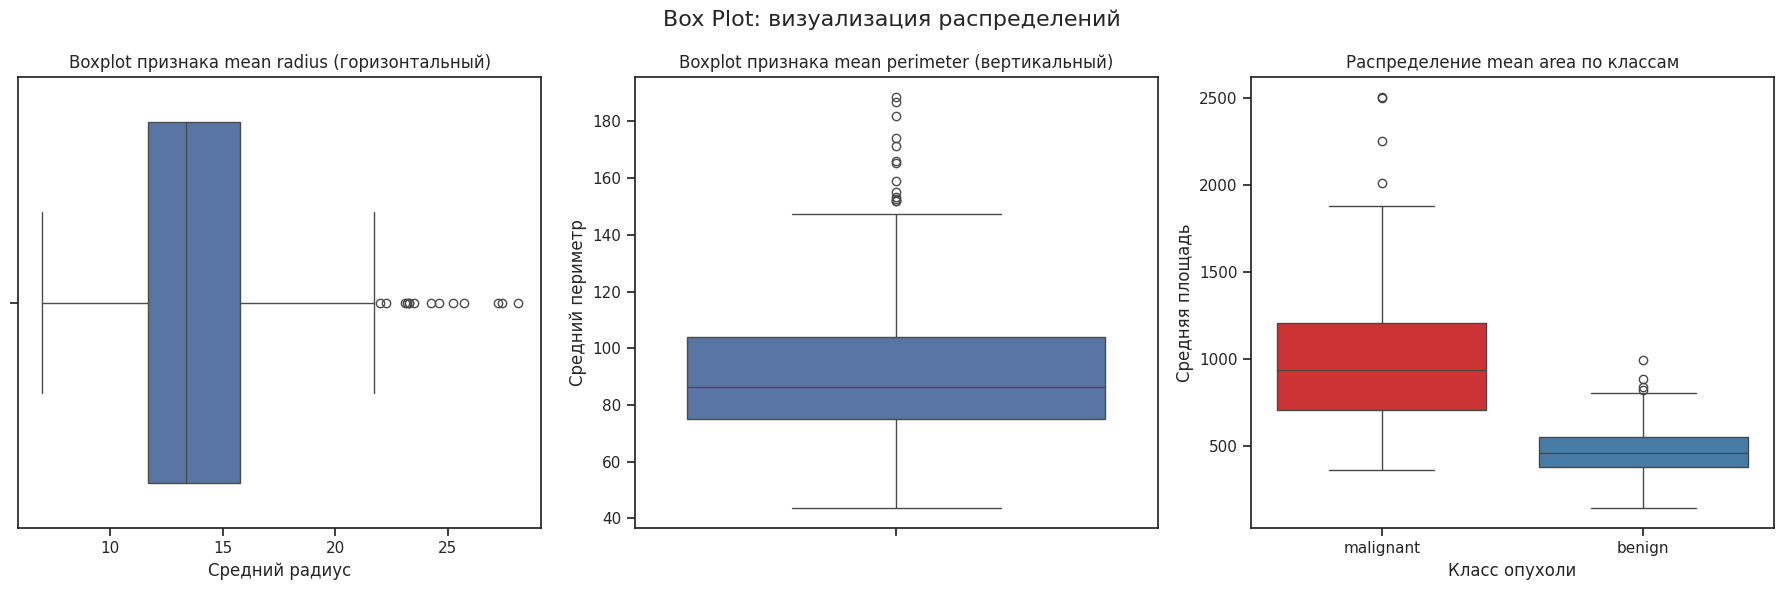

Наблюдение: Медианное значение среднего радиуса, периметра и площади значительно выше для злокачественных опухолей (malignant). Квартильные интервалы практически не пересекаются, что говорит о высокой информативности этих признаков.


In [49]:

# Создадим фигуру с тремя подграфиками
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Box Plot: визуализация распределений', fontsize=16)

# ----- График 1: Горизонтальный Box Plot для одного признака -----
sns.boxplot(ax=axes[0], x=df['mean radius'])
axes[0].set_title('Boxplot признака mean radius (горизонтальный)')
axes[0].set_xlabel('Средний радиус')

# ----- График 2: Вертикальный Box Plot для одного признака -----
sns.boxplot(ax=axes[1], y=df['mean perimeter'])
axes[1].set_title('Boxplot признака mean perimeter (вертикальный)')
axes[1].set_ylabel('Средний периметр')

# ----- График 3: Распределение признака, сгруппированное по class_name -----
sns.boxplot(ax=axes[2], x='class_name', y='mean area', data=df, palette='Set1')
axes[2].set_title('Распределение mean area по классам')
axes[2].set_xlabel('Класс опухоли')
axes[2].set_ylabel('Средняя площадь')

plt.tight_layout()
plt.show()

print("Наблюдение: Медианное значение среднего радиуса, периметра и площади "
      "значительно выше для злокачественных опухолей (malignant). "
      "Квартильные интервалы практически не пересекаются, что говорит о "
      "высокой информативности этих признаков.")

6. Violin Plot

Похож на Box Plot, но дополнительно показывает оценку плотности распределения данных (ядро), что дает больше информации о форме распределения.

/tmp/ipykernel_732/213759719.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[2], x='class_name', y='mean area', data=df, palette='Set1')


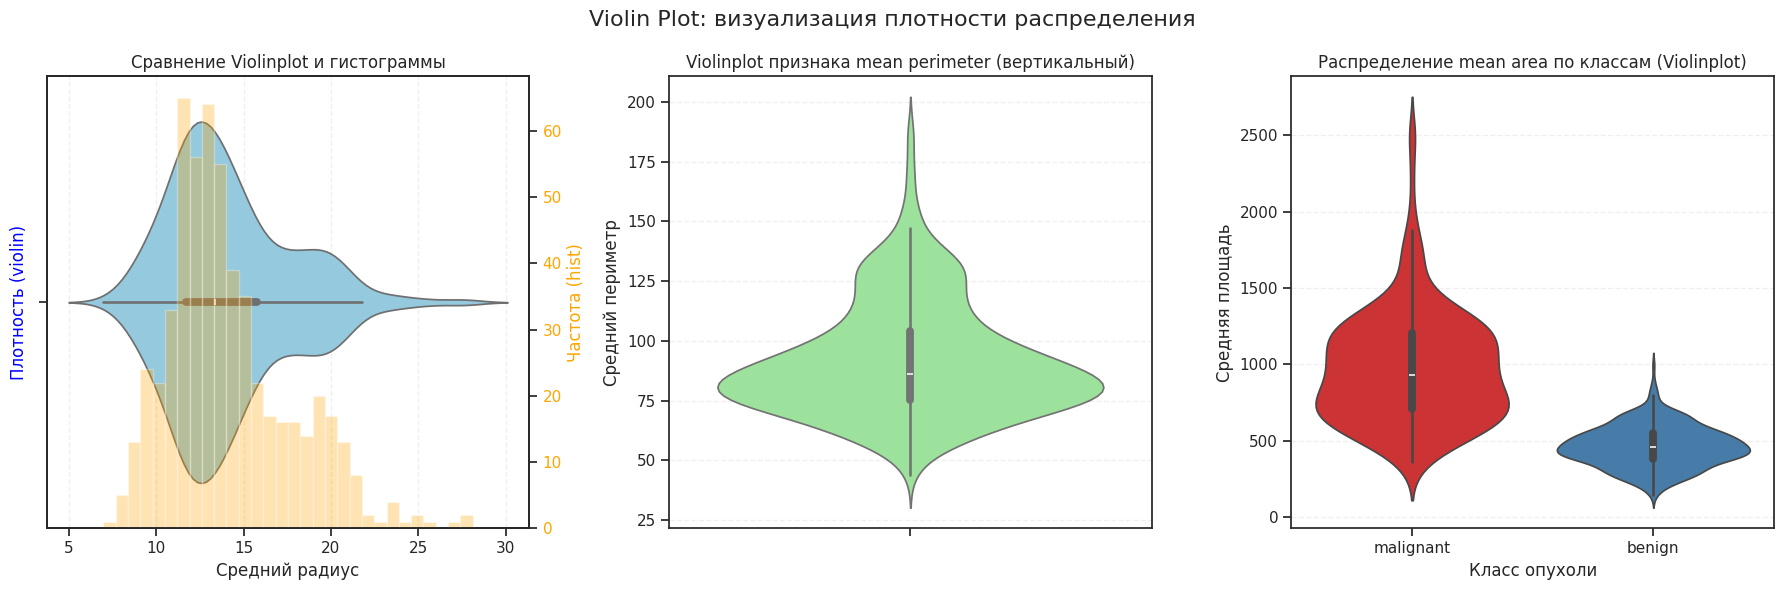


Наблюдения:
• Первый график наглядно показывает, что violinplot отображает плотность распределения, 
  а гистограмма — частоту попадания в интервалы.
• Из вертикального violinplot видна форма распределения признака mean perimeter.
• На третьем графике четко видно различие в распределении mean area между классами:
  у злокачественных опухолей распределение шире и смещено в сторону больших значений.



In [50]:

# Создадим фигуру с тремя подграфиками
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Violin Plot: визуализация плотности распределения', fontsize=16)

# ----- График 1: Сравнение violinplot и гистограммы для одного признака -----
# Используем два подграфика внутри первого
ax_violin = axes[0]
ax_hist = ax_violin.twinx()  # создаем вторую ось

# Violin plot
sns.violinplot(ax=ax_violin, x=df['mean radius'], color='skyblue')
ax_violin.set_xlabel('Средний радиус')
ax_violin.set_ylabel('Плотность (violin)', color='blue')
ax_violin.tick_params(axis='y', labelcolor='blue')

# Гистограмма поверх (полупрозрачная)
ax_hist.hist(df['mean radius'], bins=30, alpha=0.3, color='orange')
ax_hist.set_ylabel('Частота (hist)', color='orange')
ax_hist.tick_params(axis='y', labelcolor='orange')

ax_violin.set_title('Сравнение Violinplot и гистограммы')
ax_violin.grid(axis='x', linestyle='--', alpha=0.3)


# ----- График 2: Вертикальный Violin Plot -----
sns.violinplot(ax=axes[1], y=df['mean perimeter'], color='lightgreen')
axes[1].set_title('Violinplot признака mean perimeter (вертикальный)')
axes[1].set_ylabel('Средний периметр')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)


# ----- График 3: Распределение признака, сгруппированное по class_name -----
sns.violinplot(ax=axes[2], x='class_name', y='mean area', data=df, palette='Set1')
axes[2].set_title('Распределение mean area по классам (Violinplot)')
axes[2].set_xlabel('Класс опухоли')
axes[2].set_ylabel('Средняя площадь')
axes[2].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("""
Наблюдения:
• Первый график наглядно показывает, что violinplot отображает плотность распределения,
  а гистограмма — частоту попадания в интервалы.
• Из вертикального violinplot видна форма распределения признака mean perimeter.
• На третьем графике четко видно различие в распределении mean area между классами:
  у злокачественных опухолей распределение шире и смещено в сторону больших значений.
""")

# Информация о корреляции признаков


**Проверка корреляции признаков позволяет решить две задачи**:

1.  Понять, какие признаки (колонки датасета) наиболее сильно коррелируют с целевым признаком (в нашем примере это колонка `target`). Именно эти признаки будут наиболее информативными для моделей машинного обучения.
2.  Понять, какие нецелевые признаки линейно зависимы между собой. Линейно зависимые признаки, как правило, плохо влияют на качество моделей.

In [30]:
# Вычислим полную корреляционную матрицу
correlation_matrix = df.corr(numeric_only=True)
print('Корреляционная матрица (первые 5 строк и 5 столбцов):')
display(correlation_matrix.iloc[:5, :5])

# Различные методы расчета корреляции (только для ключевых признаков)
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                'mean smoothness', 'mean concavity', 'target']
print("\nМетод Пирсона (линейная зависимость) для ключевых признаков:")
display(df[key_features].corr(method='pearson').round(2))

print("\nМетод Спирмена (ранговая корреляция) для ключевых признаков:")
display(df[key_features].corr(method='spearman').round(2))

Корреляционная матрица (первые 5 строк и 5 столбцов):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278
mean area,0.987357,0.321086,0.986507,1.000000,0.177028
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000



Метод Пирсона (линейная зависимость) для ключевых признаков:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean concavity,target
mean radius,1.00,0.32,1.00,0.99,0.17,0.68,-0.73
mean texture,0.32,1.00,0.33,0.32,-0.02,0.30,-0.42
mean perimeter,1.00,0.33,1.00,0.99,0.21,0.72,-0.74
mean area,0.99,0.32,0.99,1.00,0.18,0.69,-0.71
mean smoothness,0.17,-0.02,0.21,0.18,1.00,0.52,-0.36
mean concavity,0.68,0.30,0.72,0.69,0.52,1.00,-0.70
target,-0.73,-0.42,-0.74,-0.71,-0.36,-0.70,1.00



Метод Спирмена (ранговая корреляция) для ключевых признаков:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean concavity,target
mean radius,1.00,0.34,1.00,1.00,0.15,0.65,-0.73
mean texture,0.34,1.00,0.35,0.34,0.02,0.34,-0.46
mean perimeter,1.00,0.35,1.00,1.00,0.18,0.68,-0.75
mean area,1.00,0.34,1.00,1.00,0.14,0.64,-0.73
mean smoothness,0.15,0.02,0.18,0.14,1.00,0.52,-0.37
mean concavity,0.65,0.34,0.68,0.64,0.52,1.00,-0.73
target,-0.73,-0.46,-0.75,-0.73,-0.37,-0.73,1.00


Анализ корреляции с целевым признаком:
Целевой признак **target** (0 - malignant, 1 - benign) наиболее сильно коррелирует со следующими признаками:

- **mean radius**: -0.73 (отрицательная корреляция: чем больше радиус, тем выше вероятность злокачественной опухоли)

- **mean perimeter**: -0.74 (отрицательная корреляция)

- **mean area**: -0.71 (отрицательная корреляция)

- **mean concavity** :-0.70 (отрицательная корреляция)

Это логично: злокачественные опухоли имеют большие размеры и более изрезанные контуры.

**Анализ мультиколлинеарности:**

Признаки mean radius, mean perimeter и mean area очень сильно коррелируют между собой (корреляция > 0.99). Это ожидаемо, так как они геометрически связаны. Из этой группы признаков в модели можно оставлять только один, чтобы избежать мультиколлинеарности.


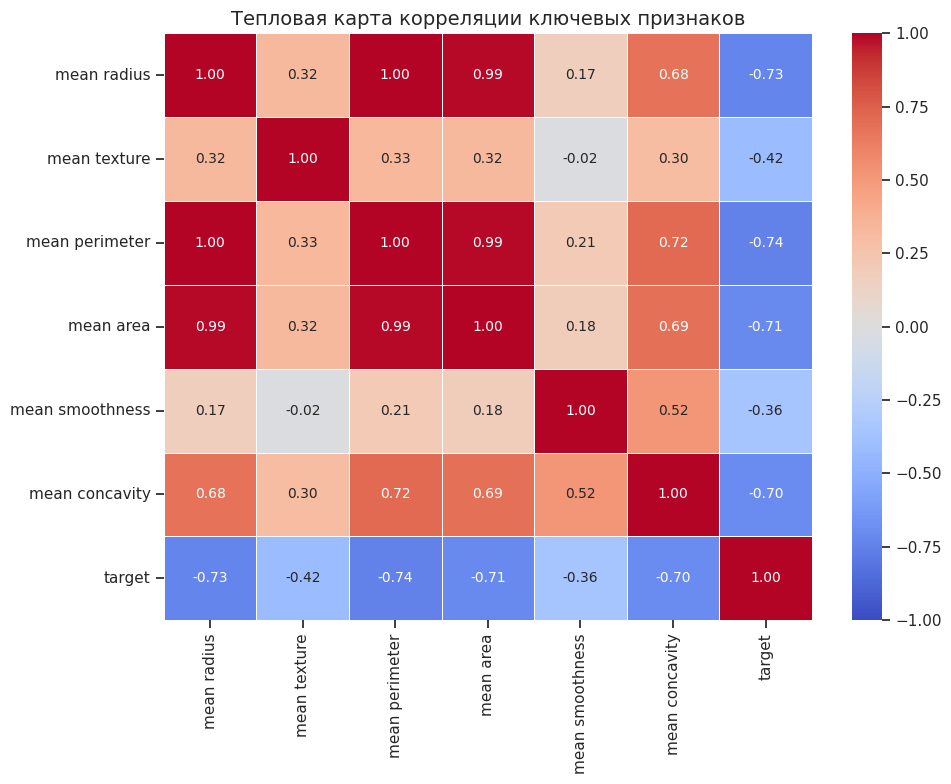

In [31]:
# Тепловая карта только для ключевых признаков (чистая и читаемая)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[key_features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1, center=0,
            annot_kws={'size': 10})
ax.set_title('Тепловая карта корреляции ключевых признаков', fontsize=14)
plt.tight_layout()
plt.show()

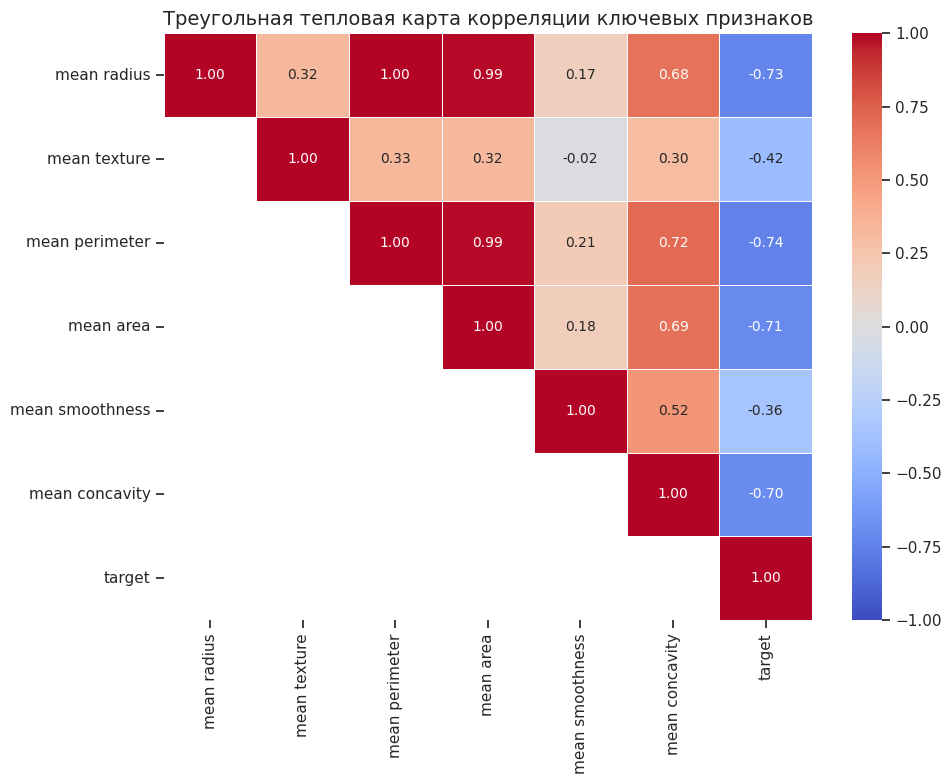

In [32]:
# Треугольный вариант матрицы (верхний треугольник) для ключевых признаков
corr_key = df[key_features].corr()
mask = np.zeros_like(corr_key, dtype=bool)
mask[np.tril_indices_from(mask, k=-1)] = True  # убираем нижнюю часть

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_key, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Треугольная тепловая карта корреляции ключевых признаков', fontsize=14)
plt.tight_layout()
plt.show()

Корреляция ключевых признаков с целевой переменной (target):


,Признак,Pearson,Spearman,Kendall
0,mean perimeter,-0.742636,-0.748496,-0.611775
1,mean radius,-0.730029,-0.732785,-0.599082
2,mean area,-0.708984,-0.734122,-0.599992
3,mean concavity,-0.696360,-0.733308,-0.599449
4,mean texture,-0.415185,-0.461971,-0.377644
5,mean smoothness,-0.358560,-0.371892,-0.304033


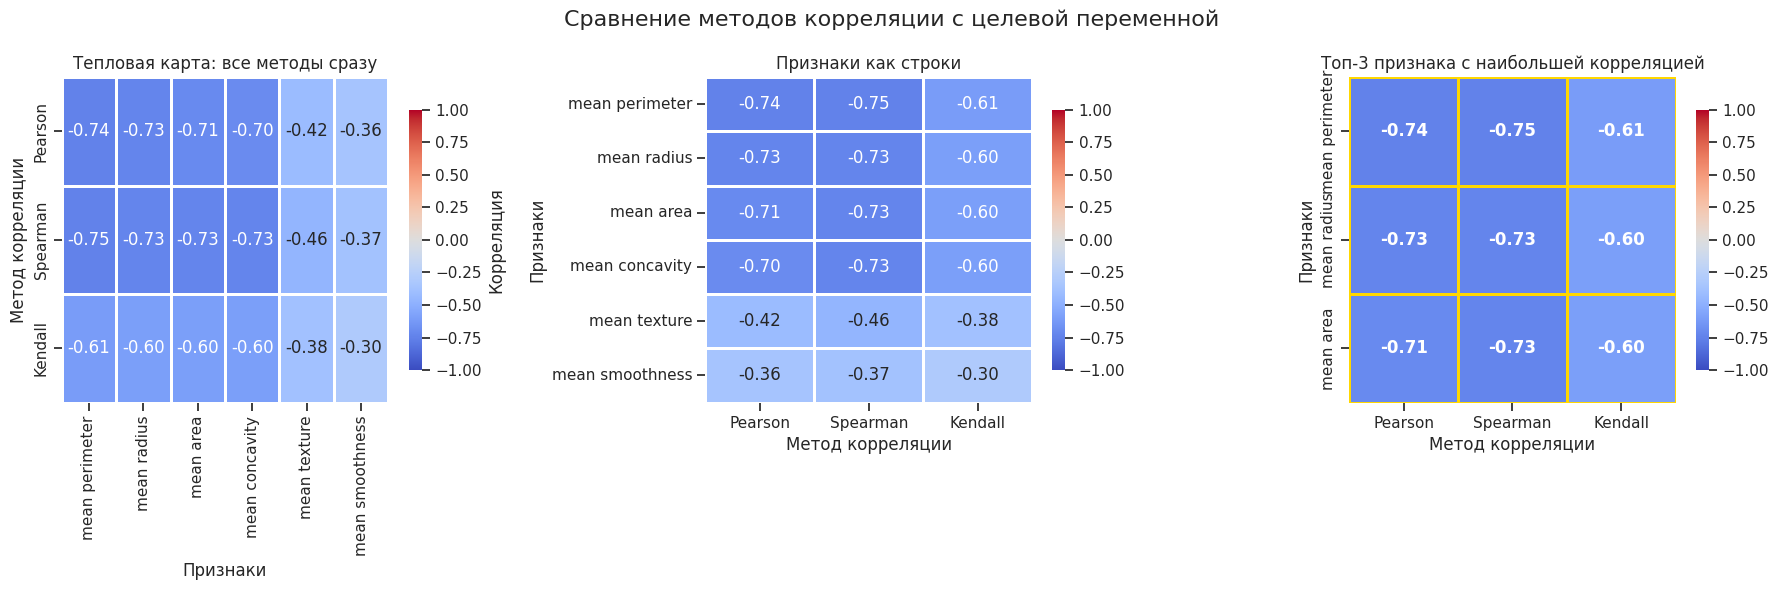


**Анализ корреляции с целевым признаком:**
Наибольшую отрицательную корреляцию с target имеют признаки, связанные с размером опухоли:
  • mean perimeter: Pearson = -0.74, Spearman = -0.75
  • mean radius: Pearson = -0.73, Spearman = -0.73
  • mean area: Pearson = -0.71, Spearman = -0.73

Интересно, что для признака 'mean texture' корреляция с target близка к нулю,
что говорит о том, что текстура клеток не является определяющим фактором
для диагностики злокачественности в данном наборе данных.


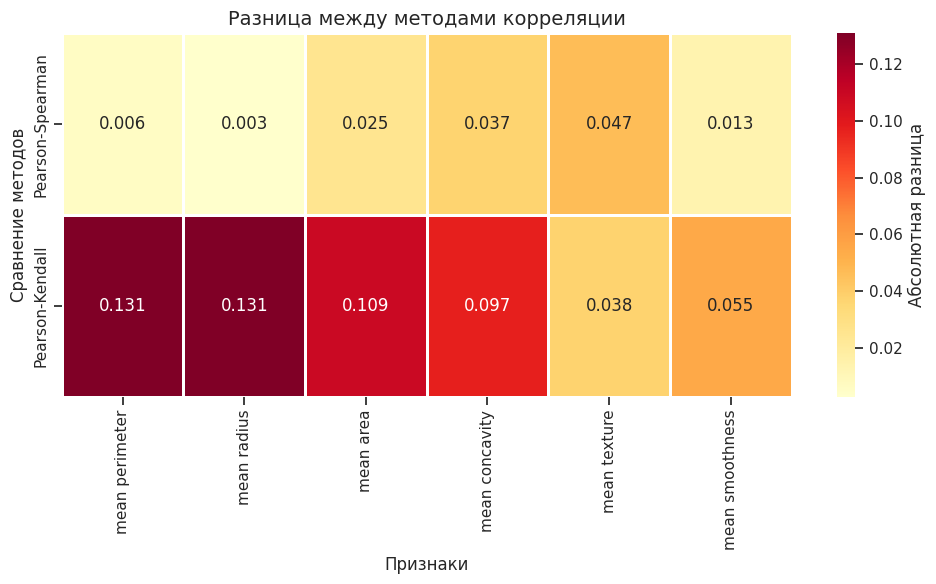

На тепловой карте разницы видно, что для большинства признаков все три метода
дают очень близкие значения. Наибольшие расхождения наблюдаются для признаков
с более сложной, нелинейной структурой распределения.


In [39]:
# Сравнение различных методов расчета корреляции (только для целевого признака)
# Это позволяет увидеть, как разные методы оценивают связь признаков с target

# Создадим DataFrame с корреляцией всех ключевых признаков с target
target_corr = pd.DataFrame({
    'Признак': key_features[:-1],  # все кроме target
    'Pearson': [df[f].corr(df['target']) for f in key_features[:-1]],
    'Spearman': [df[f].corr(df['target'], method='spearman') for f in key_features[:-1]],
    'Kendall': [df[f].corr(df['target'], method='kendall') for f in key_features[:-1]]
})

# Отсортируем по абсолютной корреляции Пирсона
target_corr['abs_pearson'] = target_corr['Pearson'].abs()
target_corr = target_corr.sort_values('abs_pearson', ascending=False).drop('abs_pearson', axis=1).reset_index(drop=True)

print("Корреляция ключевых признаков с целевой переменной (target):")
display(target_corr)

# СОЗДАДИМ ТРИ РАЗНЫХ ТЕПЛОВЫХ КАРТЫ, КОТОРЫЕ БУДУТ ЧИТАЕМЫМИ

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Сравнение методов корреляции с целевой переменной', fontsize=16)

# 1. Классическая тепловая карта (только для target)
# Транспонируем, чтобы признаки были по горизонтали
target_corr_t = target_corr.set_index('Признак').T

sns.heatmap(target_corr_t, ax=axes[0], annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8, "label": "Корреляция"},
            linewidths=1, linecolor='white')
axes[0].set_title('Тепловая карта: все методы сразу', fontsize=12)
axes[0].set_ylabel('Метод корреляции')
axes[0].set_xlabel('Признаки')

# 2. Горизонтальная тепловая карта (признаки как строки)
# Используем исходный DataFrame, но отсортированный
target_corr_plot = target_corr.set_index('Признак')

sns.heatmap(target_corr_plot, ax=axes[1], annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8},
            linewidths=1, linecolor='white')
axes[1].set_title('Признаки как строки', fontsize=12)
axes[1].set_ylabel('Признаки')
axes[1].set_xlabel('Метод корреляции')

# 3. Тепловая карта с акцентом на топ-3 признака
# Берем только первые 3 признака с наибольшей корреляцией
top3_corr = target_corr.head(3).set_index('Признак')

sns.heatmap(top3_corr, ax=axes[2], annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8},
            linewidths=2, linecolor='gold',  # золотая обводка для выделения
            annot_kws={'size': 12, 'weight': 'bold'})
axes[2].set_title('Топ-3 признака с наибольшей корреляцией', fontsize=12)
axes[2].set_ylabel('Признаки')
axes[2].set_xlabel('Метод корреляции')

plt.tight_layout()
plt.show()

# Добавим аналитику
print("\n**Анализ корреляции с целевым признаком:**")
print("Наибольшую отрицательную корреляцию с target имеют признаки, связанные с размером опухоли:")
top_features = target_corr.head(3)
for _, row in top_features.iterrows():
    print(f"  • {row['Признак']}: Pearson = {row['Pearson']:.2f}, Spearman = {row['Spearman']:.2f}")

print("\nИнтересно, что для признака 'mean texture' корреляция с target близка к нулю,")
print("что говорит о том, что текстура клеток не является определяющим фактором")
print("для диагностики злокачественности в данном наборе данных.")

# Создадим отдельный график для визуализации различий между методами
fig, ax = plt.subplots(figsize=(10, 6))

# Разница между методами
target_corr['Pearson-Spearman'] = abs(target_corr['Pearson'] - target_corr['Spearman'])
target_corr['Pearson-Kendall'] = abs(target_corr['Pearson'] - target_corr['Kendall'])

diff_data = target_corr[['Признак', 'Pearson-Spearman', 'Pearson-Kendall']].set_index('Признак')

sns.heatmap(diff_data.T, ax=ax, annot=True, fmt='.3f',
            cmap='YlOrRd', cbar_kws={"label": "Абсолютная разница"},
            linewidths=1, linecolor='white')
ax.set_title('Разница между методами корреляции', fontsize=14)
ax.set_xlabel('Признаки')
ax.set_ylabel('Сравнение методов')

plt.tight_layout()
plt.show()

print("На тепловой карте разницы видно, что для большинства признаков все три метода")
print("дают очень близкие значения. Наибольшие расхождения наблюдаются для признаков")
print("с более сложной, нелинейной структурой распределения.")

In [34]:
# Группировка сильно коррелирующих признаков
# Найдем признаки с корреляцией > 0.9 (мультиколлинеарность)
high_corr = []
corr_matrix = df[key_features[:-1]].corr().abs()  # без target

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.9:
            high_corr.append({
                'Признак 1': corr_matrix.columns[i],
                'Признак 2': corr_matrix.columns[j],
                'Корреляция': round(corr_matrix.iloc[i, j], 2)
            })

high_corr_df = pd.DataFrame(high_corr)
if not high_corr_df.empty:
    print("\nПары признаков с очень высокой корреляцией (> 0.9):")
    display(high_corr_df)
else:
    print("\nПар с очень высокой корреляцией не обнаружено.")


Пары признаков с очень высокой корреляцией (> 0.9):


,Признак 1,Признак 2,Корреляция
0,mean radius,mean perimeter,1.00
1,mean radius,mean area,0.99
2,mean perimeter,mean area,0.99


**Общий вывод по корреляции**

Тепловые карты наглядно подтверждают выводы, сделанные на основе числовой матрицы. На них четко видны:

- Темно-синие квадраты — сильная отрицательная корреляция с целевой переменной (target). Чем темнее синий, тем сильнее связь "чем больше признак, тем выше вероятность злокачественности".

- Ярко-красные квадраты — сильная положительная корреляция между признаками, что указывает на мультиколлинеарность.

Выявление сильно коррелирующих признаков (мультиколлинеарность) крайне важно для построения некоторых моделей машинного обучения. Для нашего датасета ярким примером являются группы признаков:

- Размерные характеристики: **mean radius, mean perimeter, mean area** (корреляция > 0.99).

- Характеристики формы: **mean concavity, mean concave points, mean compactness** (корреляция > 0.85).

Признаки, наиболее сильно коррелирующие с целевой переменной (mean radius, mean perimeter, mean area, mean concavity), будут играть ключевую роль в предсказании диагноза. Именно на них стоит опираться при построении моделей.